# Hello, Graph World
**Joao De Oliveira**

**Assignment:** build the nodes and edges of a basic graph and deliver it in an IPython notebook.

The graph used here is the **Krackhardt kite**, a small ten-person social network that David Krackhardt
designed in 1990. Tthe most central person changes depending on which definition of centrality we use, 
which makes it a nice first graph to reason about.

My plan for this notebook:

1. Build the kite from scratch, node by node and edge by edge.
2. Inspect the basic structure: size, density, degrees.
3. Draw it in the same layout as in the instructions for the assignment.
4. Compute four centrality measures and compare who wins under each.
5. Check the hand-built graph against NetworkX's built-in kite to check if it was assembled correctly.
6. Export the graph.


## 1. Setup

In [113]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 120)

print(f"networkx   {nx.__version__}")
print(f"pandas     {pd.__version__}")

networkx   3.4.2
pandas     2.3.3


## 2. Build the graph

The whole point of a "beachhead" program is to do the basic thing by hand, so the kite is
assembled explicitly.

I will use an undirected graph since the relationships in the kite are mutual friendships.

In [114]:
# empty undirected graph
K = nx.Graph(name="Krackhardt Kite")

# nodes: ten people
people = [
    "Andre", "Beverly", "Carol", "Diane", "Ed",
    "Fernando", "Garth", "Heather", "Ike", "Jane",
]
K.add_nodes_from(people)

# edges: 18 mutual friendships
friendships = [
    ("Andre", "Beverly"),
    ("Andre", "Carol"),
    ("Andre", "Diane"),
    ("Andre", "Fernando"),
    ("Beverly", "Diane"),
    ("Beverly", "Ed"),
    ("Beverly", "Garth"),
    ("Carol", "Diane"),
    ("Carol", "Fernando"),
    ("Diane", "Ed"),
    ("Diane", "Fernando"),
    ("Diane", "Garth"),
    ("Ed", "Garth"),
    ("Fernando", "Garth"),
    ("Fernando", "Heather"),
    ("Garth", "Heather"),
    ("Heather", "Ike"),
    ("Ike", "Jane"),
]
K.add_edges_from(friendships)

print(f"Graph name : {K.name}")
print(f"Nodes      : {K.number_of_nodes()}")
print(f"Edges      : {K.number_of_edges()}")

Graph name : Krackhardt Kite
Nodes      : 10
Edges      : 18


### 2a. Basic structure

In [115]:
# graph properties
summary = {
    "Nodes": K.number_of_nodes(),
    "Edges": K.number_of_edges(),
    "Density": round(nx.density(K), 4),
    "Connected?": nx.is_connected(K),
    "Diameter (longest shortest path)": nx.diameter(K),
    "Average shortest path length": round(nx.average_shortest_path_length(K), 4),
    "Average clustering coefficient": round(nx.average_clustering(K), 4),
}

print("STRUCTURAL SUMMARY")
print("-" * 46)
for label, value in summary.items():
    print(f"{label:<34}{value}")

STRUCTURAL SUMMARY
----------------------------------------------
Nodes                             10
Edges                             18
Density                           0.4
Connected?                        True
Diameter (longest shortest path)  4
Average shortest path length      1.9778
Average clustering coefficient    0.52


In [116]:
# connections per person (degree)
degrees = (
    pd.DataFrame(K.degree(), columns=["Person", "Degree"])
    .sort_values("Degree", ascending=False)
    .reset_index(drop=True)
)

print("DEGREE PER PERSON")
print("-" * 46)
print(degrees.to_string(index=False))
print("-" * 46)
print(f"Sum of degrees = {degrees['Degree'].sum()} "
      f"(should be 2 x {K.number_of_edges()} edges = {2 * K.number_of_edges()})")

DEGREE PER PERSON
----------------------------------------------
  Person  Degree
   Diane       6
Fernando       5
   Garth       5
   Andre       4
 Beverly       4
   Carol       3
      Ed       3
 Heather       3
     Ike       2
    Jane       1
----------------------------------------------
Sum of degrees = 36 (should be 2 x 18 edges = 36)


## 3. Draw the graph

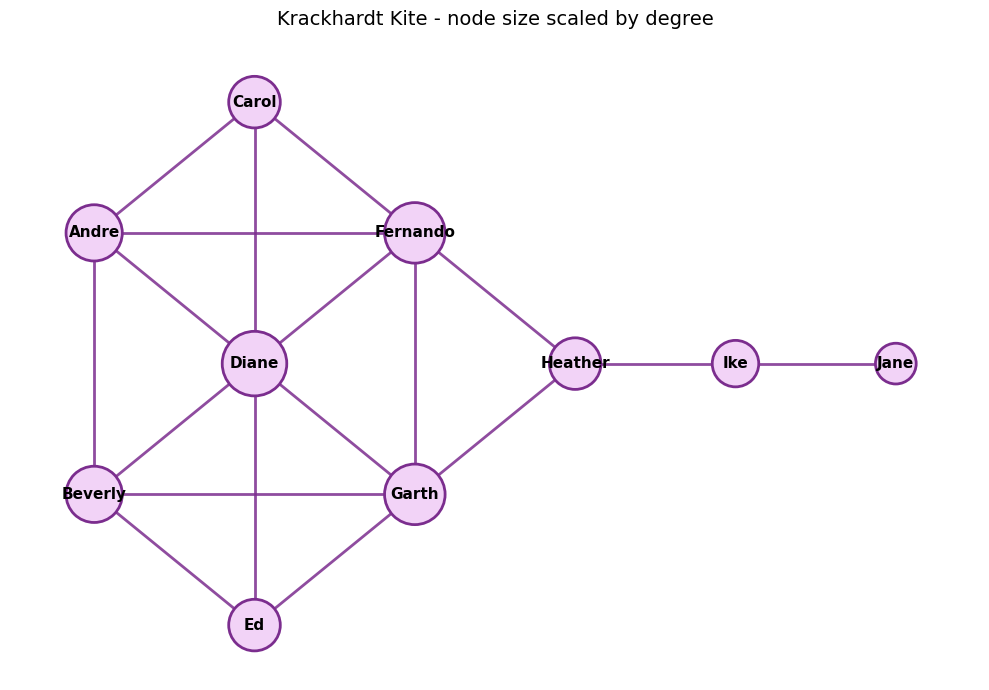

In [117]:
# coordinates 
pos = {
    "Carol":    (1, 4),
    "Andre":    (0, 3),
    "Fernando": (2, 3),
    "Diane":    (1, 2),
    "Heather":  (3, 2),
    "Ike":      (4, 2),
    "Jane":     (5, 2),
    "Beverly":  (0, 1),
    "Garth":    (2, 1),
    "Ed":       (1, 0),
}

node_sizes = [600 + 260 * K.degree(n) for n in K.nodes()]

fig, ax = plt.subplots(figsize=(10, 7))

nx.draw_networkx_edges(K, pos, ax=ax, width=2.0, edge_color="#7B2D8E", alpha=0.85)
nx.draw_networkx_nodes(K, pos, ax=ax, node_size=node_sizes,
                       node_color="#F2D3F7", edgecolors="#7B2D8E", linewidths=2)
nx.draw_networkx_labels(K, pos, ax=ax, font_size=11, font_weight="bold")

ax.set_title("Krackhardt Kite - node size scaled by degree", fontsize=14, pad=16)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Centrality: who is the most important person?

Four different measures are computed below.

| Measure | Question it answers |
|---|---|
| **Degree** | Who has the most direct connections? |
| **Betweenness** | Who sits on the most shortest paths between other people? |
| **Closeness** | Who can reach everyone else in the fewest hops on average? |
| **Eigenvector** | Who is connected to other well-connected people? |

The kite is famous precisely because these four give three different winners.

In [118]:
# Compute all four measures
centrality = pd.DataFrame({
    "Degree":      nx.degree_centrality(K),
    "Betweenness": nx.betweenness_centrality(K),
    "Closeness":   nx.closeness_centrality(K),
    "Eigenvector": nx.eigenvector_centrality(K, max_iter=1000),
}).round(4)

centrality.index.name = "Person"
centrality = centrality.sort_values("Degree", ascending=False)

print("CENTRALITY SCORES")
print("=" * 66)
print(centrality.to_string())

CENTRALITY SCORES
          Degree  Betweenness  Closeness  Eigenvector
Person                                               
Diane     0.6667       0.1019     0.6000       0.4810
Fernando  0.5556       0.2315     0.6429       0.3977
Garth     0.5556       0.2315     0.6429       0.3977
Andre     0.4444       0.0231     0.5294       0.3522
Beverly   0.4444       0.0231     0.5294       0.3522
Carol     0.3333       0.0000     0.5000       0.2858
Ed        0.3333       0.0000     0.5000       0.2858
Heather   0.3333       0.3889     0.6000       0.1959
Ike       0.2222       0.2222     0.4286       0.0481
Jane      0.1111       0.0000     0.3103       0.0112


In [119]:
# top scorer per measure
print("TOP PERSON BY MEASURE")
print("=" * 66)
for measure in centrality.columns:
    winner = centrality[measure].idxmax()
    score = centrality[measure].max()
    print(f"{measure:<14} -> {winner:<10} ({score:.4f})")

print()
print("RANK ORDER UNDER EACH MEASURE")
print("=" * 66)
ranks = pd.DataFrame({
    m: centrality[m].rank(ascending=False, method="min").astype(int)
    for m in centrality.columns
})
print(ranks.sort_values("Degree").to_string())

TOP PERSON BY MEASURE
Degree         -> Diane      (0.6667)
Betweenness    -> Heather    (0.3889)
Closeness      -> Fernando   (0.6429)
Eigenvector    -> Diane      (0.4810)

RANK ORDER UNDER EACH MEASURE
          Degree  Betweenness  Closeness  Eigenvector
Person                                               
Diane          1            5          3            1
Fernando       2            2          1            2
Garth          2            2          1            2
Andre          4            6          5            4
Beverly        4            6          5            4
Carol          6            8          7            6
Ed             6            8          7            6
Heather        6            1          3            8
Ike            9            4          9            9
Jane          10            8         10           10


### What the numbers say

- **Diane wins on degree.** She has six direct friends, more than anyone. But when we look at who they are,
  we understand that all six are people who are already connected to each other, so while she is at the center,
  her connections are partly redundant. Her friends would still reach each other if she is removed.

- **Heather wins on betweenness.** She only has three connections, half of Diane's, but one of them is
  Ike, and Ike is the only route to Jane. Heather is the bridge between the dense cluster on the left
  and the tail on the right. Remove Heather and the network splits in two.

- **Fernando and Garth tie on closeness.** Neither is the most connected, but both sit between the
  dense cluster and Heather's bridge, so they reach the whole network in fewer average hops than
  anyone else. They are the best positioned to spread information quickly.

- **Diane wins on eigenvector** as well, since eigenvector centrality rewards being connected to
  other well connected people, which is exactly the clique she sits in.

So, the person with the most friends is not automatically the most powerful person in a network.
Heather's position, not her popularity, is what makes her structurally important. Jane, with a 
single connection, is the most peripheral person by every measure, as expected.

In [120]:
# showing that removing Heather disconnects the graph
for person in ["Heather", "Diane", "Jane"]:
    test = K.copy()
    test.remove_node(person)
    still_connected = nx.is_connected(test)
    components = nx.number_connected_components(test)
    status = "stays in one piece" if still_connected else "SPLITS APART"
    print(f"Remove {person:<9} -> {components} component(s), network {status}")

Remove Heather   -> 2 component(s), network SPLITS APART
Remove Diane     -> 1 component(s), network stays in one piece
Remove Jane      -> 1 component(s), network stays in one piece


## 5. Validate the hand-built graph

NetworkX ships with the kite built in. It uses integer labels 0-9 instead of names, so the check
below relabels them and confirms the two graphs are identical. If the edge list above had a typo,
this cell would catch it.

In [121]:
builtin = nx.krackhardt_kite_graph()
mapping = dict(zip(range(10), sorted(people)))
builtin = nx.relabel_nodes(builtin, mapping)

same_nodes = set(K.nodes()) == set(builtin.nodes())
same_edges = set(map(frozenset, K.edges())) == set(map(frozenset, builtin.edges()))

print("VALIDATION AGAINST nx.krackhardt_kite_graph()")
print("-" * 50)
print(f"Node sets match : {same_nodes}")
print(f"Edge sets match : {same_edges}")
print(f"Graphs isomorphic: {nx.is_isomorphic(K, builtin)}")
print("-" * 50)
print("PASS - hand-built graph is correct." if (same_nodes and same_edges)
      else "FAIL - check the edge list above.")

VALIDATION AGAINST nx.krackhardt_kite_graph()
--------------------------------------------------
Node sets match : True
Edge sets match : True
Graphs isomorphic: True
--------------------------------------------------
PASS - hand-built graph is correct.


## 6. Adjacency matrix and export

The adjacency matrix is the same graph written as a table where a 1 means those two people are connected.
It is worth printing once because it is the form most other tools expect.

In [122]:
# adjacency matrix
order = sorted(K.nodes())
adjacency = nx.to_pandas_adjacency(K, nodelist=order, dtype=int)

print("ADJACENCY MATRIX")
print("=" * 66)
print(adjacency.to_string())

ADJACENCY MATRIX
          Andre  Beverly  Carol  Diane  Ed  Fernando  Garth  Heather  Ike  Jane
Andre         0        1      1      1   0         1      0        0    0     0
Beverly       1        0      0      1   1         0      1        0    0     0
Carol         1        0      0      1   0         1      0        0    0     0
Diane         1        1      1      0   1         1      1        0    0     0
Ed            0        1      0      1   0         0      1        0    0     0
Fernando      1        0      1      1   0         0      1        1    0     0
Garth         0        1      0      1   1         1      0        1    0     0
Heather       0        0      0      0   0         1      1        0    1     0
Ike           0        0      0      0   0         0      0        1    0     1
Jane          0        0      0      0   0         0      0        0    1     0


In [123]:
# save the graph and the results 
nx.write_gexf(K, "krackhardt_kite.gexf")      # opens in Gephi
nx.write_edgelist(K, "krackhardt_kite.edgelist", data=False)
centrality.to_csv("kite_centrality.csv")

print("Files written:")
for f in ["krackhardt_kite.gexf", "krackhardt_kite.edgelist", "kite_centrality.csv"]:
    print(f"  - {f}")

Files written:
  - krackhardt_kite.gexf
  - krackhardt_kite.edgelist
  - kite_centrality.csv


## 7. Conclusion

The kite was built from scratch as 10 nodes and 18 edges, drawn, measured, and verified against
the built-in NetworkX version. It is important to note that the four centrality measures do not
agree: Diane has the most connections, Heather controls the only bridge in the network, and
Fernando and Garth are best placed to reach everyone quickly. Which of them counts as "most
central" depends entirely on what we are trying to do with the network.

https://github.com/JDO-MSDS/DATA-620/tree/main/AssignmentHelloGraph 